# A rendre

Ce TP est à rendre pour le 1 mars 2026 pour les étudiant(e)s non alternants. Les alternant(e)s ont une semaine de plus (soumission avant le 08 mars à 23h59).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Exercice 1

* Chargez les données San_People_stats1.csv. Décrivez les données.  Quelle est la distribution des âges? Des sexes?
* Visualisez les données (scatter) en utilisant les 2 premières colonnes. Colorisez en fonction de l'âge. Que constatez vous?
* On veut prédire l'âge des individus.
* En utilisant comme domaine des instances l'espace décrit par les variables height et weight entraînez un modèle linéaire, un modéle de k-plus proches voisins, un modèle par Noyau ou polynômes locaux. Expliquez comment vous choisissez les paramètres de Knn, Noyau. Comparez les 3 modèles


In [2]:
data = pd.read_csv('../supervisé/data/San_People_stats1.csv', sep=';')
data.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


#### Description des données

In [3]:
# description des données
data.describe()

,height,weight,age,male
count,544.000000,544.000000,544.000000,544.000000
mean,138.263596,35.610618,29.344393,0.472426
std,27.602448,14.719178,20.746888,0.499699
min,53.975000,4.252425,0.000000,0.000000
25%,125.095000,22.007717,12.000000,0.000000
50%,148.590000,40.057844,27.000000,0.000000
75%,157.480000,47.209005,43.000000,1.000000
max,179.070000,62.992589,88.000000,1.000000


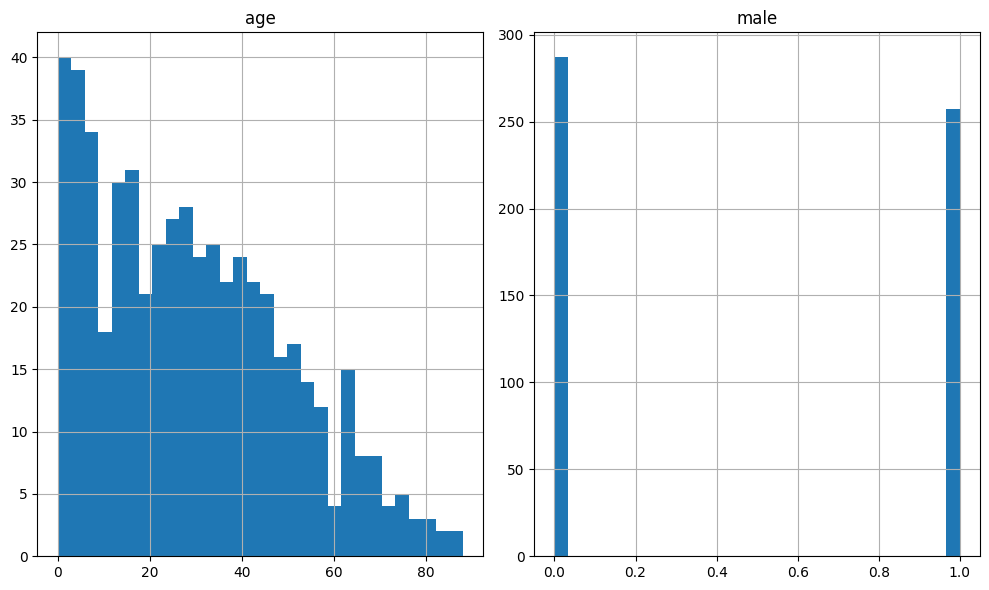

In [4]:
# Visualisation des distributions des variables
data[["age", "male"]].hist(bins=30, figsize=(10, 6))
plt.tight_layout()
plt.show()

### Scatter plot

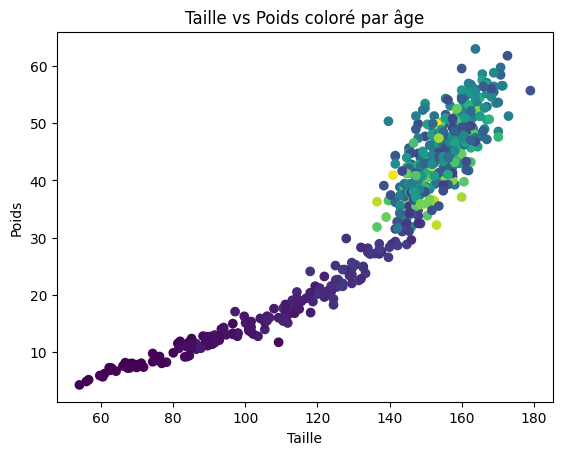

23    13.0
18    12.0
19     8.0
24     7.0
20     6.5
Name: age, dtype: float64

In [5]:
# Visualisation des données avec coloration selon la variable age
from matplotlib import colormaps
plt.scatter(data['height'], data['weight'], c=data['age'], cmap=colormaps['viridis'])
plt.xlabel('Taille')
plt.ylabel('Poids')
plt.title('Taille vs Poids coloré par âge')
plt.show()

age_fixe = data['age'][(data["height"] <= 140) & (data["weight"] <= 30)]
age_fixe.head().sort_values(ascending=False)

Le graphique montre une relation croissante entre la taille et le poids. La croissance est simultanée pour les premières tranches d’age(age <=13),puis la taille se stabilise à partir d'un certain seuil(160) tandis que le poids continue d’augmenter, avec une variabilité croissante. Les classes d’age se recouvrent partiellement. Cette visualisation reflète bien la réalité car à un certain age, l'individu
peut prendre de poids mais sa taille cesse d'augmenter.

### Modèle linéaire

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data[['height', 'weight']], data['age'], test_size=1/3,train_size=2/3, random_state=42)

In [7]:
from sklearn.linear_model import LinearRegression
model_lin = LinearRegression()
model_lin.fit(x_train, y_train)
y_pred = model_lin.predict(x_test)
R_squared_lin = model_lin.score(x_test, y_test)
print(f"R² du modèle linéaire : {R_squared_lin:.4f}")

R² du modèle linéaire : 0.4777


### Modèle K-plus proches voisins

In [8]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
# on effectue une recherche du meilleur k
init_knn = KNeighborsRegressor(n_neighbors=1)
init_knn.fit(x_train, y_train)
# calcul des erreurs minimales pour k=1
mse_init_empirique = mean_squared_error(y_train, init_knn.predict(x_train))
mse_init_generalisation = mean_squared_error(y_test, init_knn.predict(x_test))
# listes pour stocker les MSE
liste_mse_generalisation = [mse_init_generalisation]
liste_mse_empirique = [mse_init_empirique]
# boucle pour k de 2 à 99
for k in range(2, 100):
    model_knn = KNeighborsRegressor(n_neighbors=k)
    model_knn.fit(x_train, y_train)
    y_pred_gen = model_knn.predict(x_test)
    y_pred_emp = model_knn.predict(x_train)
    liste_mse_generalisation.append(mean_squared_error(y_test, y_pred_gen))
    liste_mse_empirique.append(mean_squared_error(y_train, y_pred_emp))

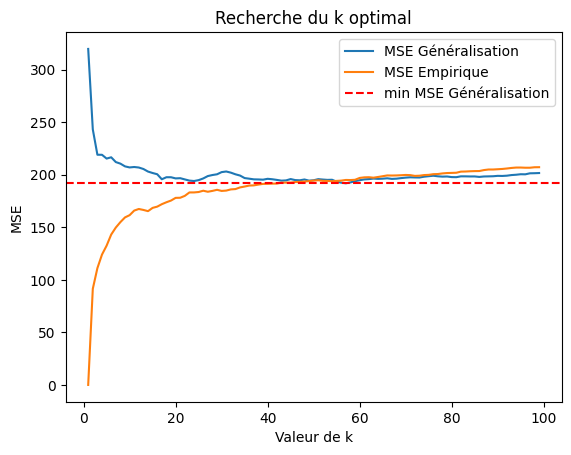

In [9]:
# Conseil : Pour visualiser votre recherche
plt.plot(range(1, 100), liste_mse_generalisation, label='MSE Généralisation')
plt.plot(range(1, 100), liste_mse_empirique, label='MSE Empirique')
plt.axhline(y=min(liste_mse_generalisation), color='r', linestyle='--', label='min MSE Généralisation')
plt.legend()
plt.xlabel('Valeur de k')
plt.ylabel('MSE')
plt.title('Recherche du k optimal')
plt.show()

L'analyse des courbes d'évolution des erreurs d'entraînement et de test permet d'identifier la zone de performance optimale du modèle.L'observation visuelle indique que le meilleur k se situe entre 1 et 20. En dehors de cet intervalle, le modèle perd soit en précision locale (trop de lissage), soit en stabilité (trop de bruit). Pour choisir le k final(best_k), nous nous basons exclusivement sur l'erreur de test. Contrairement à l'erreur d'entraînement qui est biaisée (elle tend vers zéro quand k=1), l'erreur de généralisation nous permet de mesurer la capacité du modèle à traiter des données qu'il n'a jamais rencontrées. La boucle de recherche permet d'automatiser ce choix en testant chaque valeur de k dans l'intervalle défini. Elle identifie le point où le modèle atteint le meilleur équilibre.

In [11]:
min_mse = []
for i in range(1, 20):
    model_knn = KNeighborsRegressor(n_neighbors=i)
    model_knn.fit(x_train, y_train)
    y_pred = model_knn.predict(x_test)
    min_mse.append(mean_squared_error(y_test, y_pred))
best_k = np.argmin(min_mse) + 1
print(f"Le meilleur k est {best_k} avec un MSE de {min_mse[best_k-1]}")

Le meilleur k est 17 avec un MSE de 195.6928013897867


In [12]:
model_knn_final = KNeighborsRegressor(n_neighbors=best_k)
model_knn_final.fit(x_train, y_train)
y_pred_knn_final = model_knn_final.predict(x_test)
R_squared_knn_final = model_knn_final.score(x_test, y_test)
print(f"R² du modèle KNN final : {R_squared_knn_final:.4f}")

R² du modèle KNN final : 0.5730


### Modèle par noyau ou polynômes locaux

In [13]:
## modèle par noyau ou polynômes locaux
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
modele_kde = KernelDensity(kernel='gaussian')
param_grid = {'bandwidth': np.linspace(0.1, 1.0, 10)}
grid_search = GridSearchCV(modele_kde, param_grid, cv=5)
grid_search.fit(x_train)
best_bandwidth = grid_search.best_params_['bandwidth']
print(f"Le meilleur bandwidth est {best_bandwidth}")
modele_kde = KernelDensity(kernel='gaussian', bandwidth=best_bandwidth)
modele_kde.fit(x_train)
y_pred_kde = modele_kde.score_samples(x_test)
mse_kde = mean_squared_error(y_test, np.exp(y_pred_kde))
print(f"MSE du modèle KDE : {mse_kde}")

Le meilleur bandwidth est 1.0
MSE du modèle KDE : 1345.3495601522932


## Exercice 2


Soit la base de données Boston contenant 13 attributs (criminalité, zonage, entreprises, distance par rapport au fleuve Charles, concentration en oxydes d'azote, nombre de pièces, unités occupées par le propriétaire, distance moyenne vers les centres d'emploi, accessibilité aux autoroutes radiales, taux d'imposition, ratio élève/enseignant, pourcentage de statut inférieur, valeur médiane des résidences occupées par le propriétaire) et 506 entrées. Utilisez la mèthode des  $𝑘$- plus-proches-voisins pour apprendre un modèle capable de prédire le taux de criminalité en fonction des autres attributs (faites au préalable une analyse descriptive des attributs, une sélection des attributs pour un meilleur modèle). Utilisez la validation croisée pour sélection le nombre de voisins $k$.


In [14]:
data = pd.read_csv('../supervisé/data/Boston.csv', sep=',')
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### Analyse descriptive des attributs

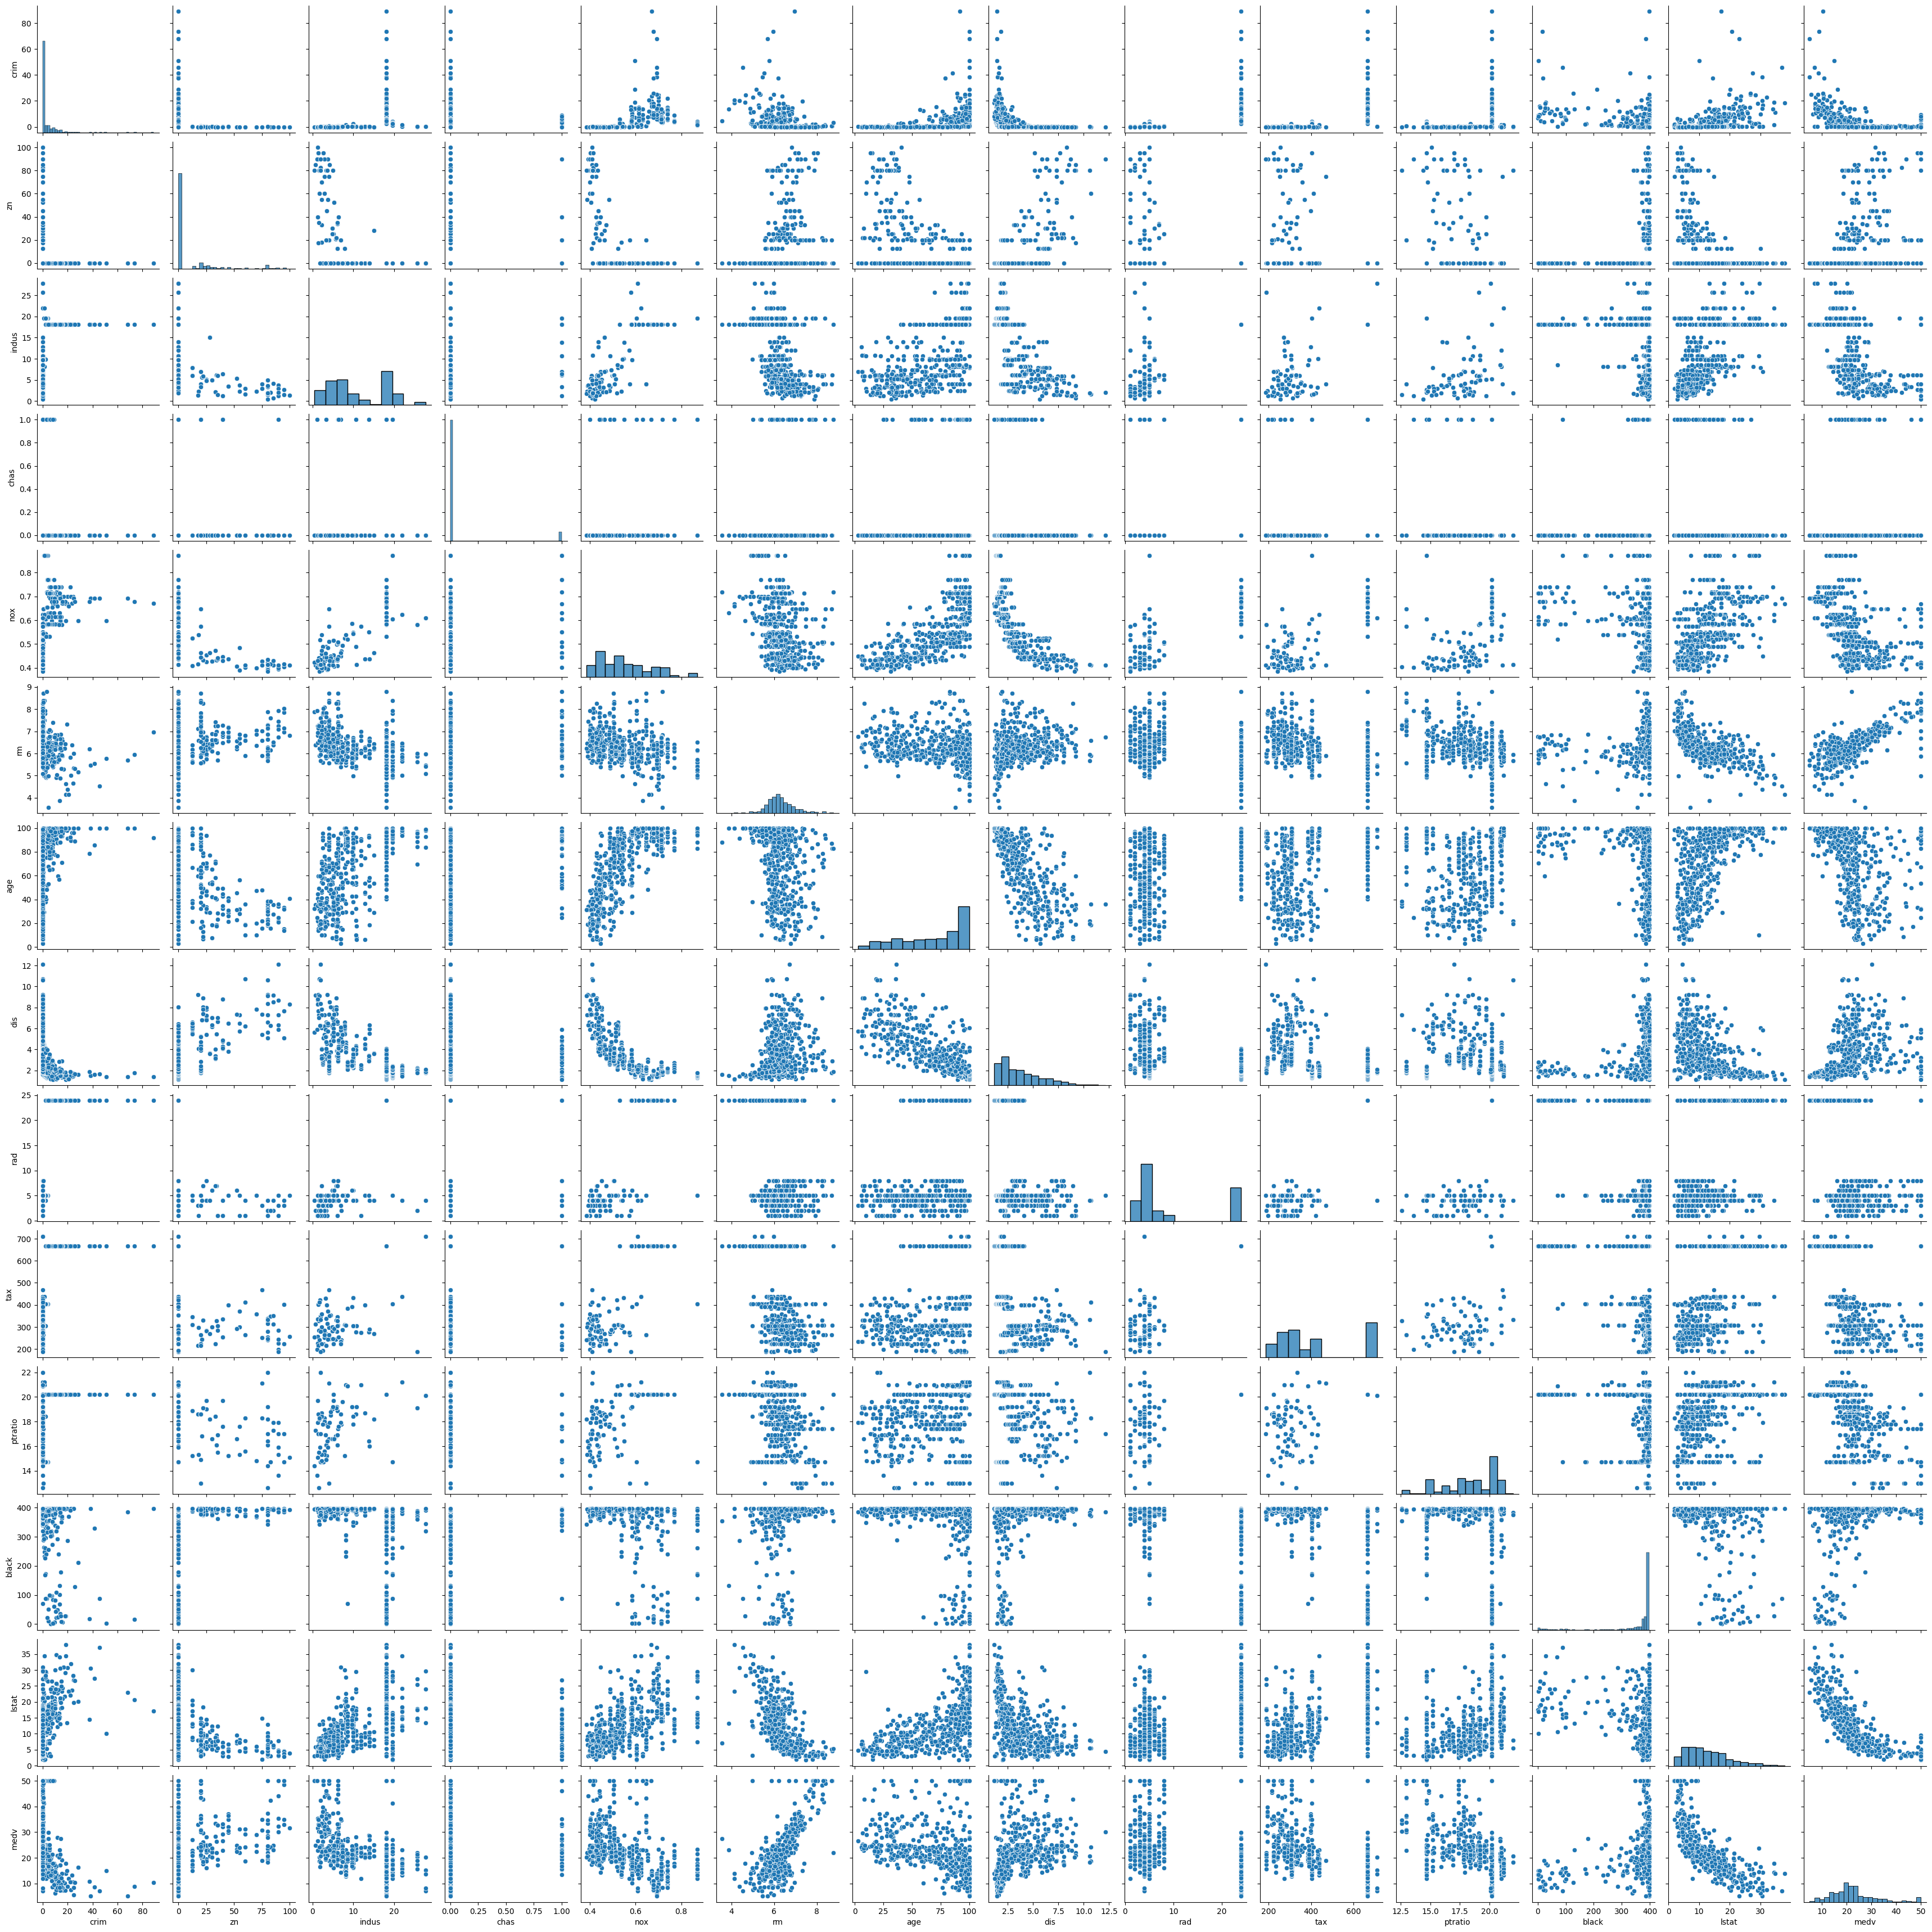

In [15]:
#sns.pairplot(data, x_vars=X_Boston.columns, y_vars='crim', kind='scatter')
sns.pairplot(data, kind='scatter')
plt.show()

In [16]:
## analyse descriptive des attributs
data.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


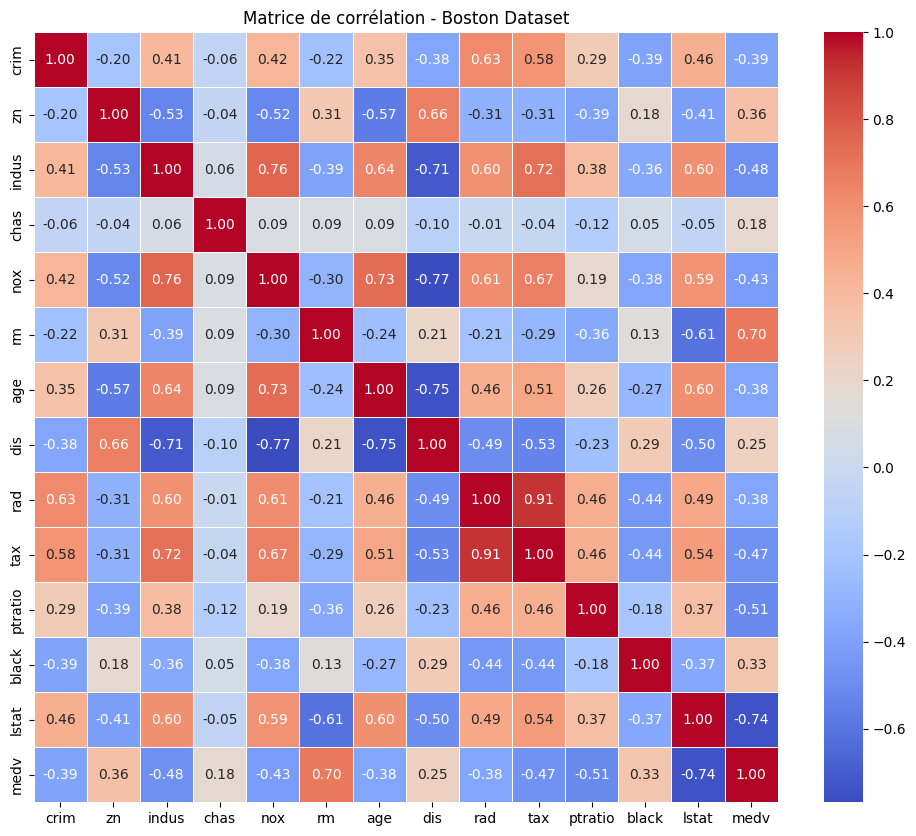

In [17]:

corr_matrix = data.corr()

# Affichage avec les valeurs numériques
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",      # palette de couleurs
    annot=True,          # affiche les nombres
    fmt=".2f",           # 2 décimales
    linewidths=0.5       # lignes entre cases
)

plt.title("Matrice de corrélation - Boston Dataset")
plt.show()


In [107]:
## definition d'un seuil de corrélation pour identifier les paires de variables fortement corrélées
threshold = 0.7

# Masque pour éviter doublons et diagonale
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
)
## Extraction des paires de variables fortement corrélées
strong_pairs = corr_pairs.stack()[abs(corr_pairs.stack()) > threshold]

print("Paires de variables fortement corrélées :")
print(strong_pairs)
seconde_variable = strong_pairs[0]

Paires de variables fortement corrélées :
indus  nox     0.763651
       dis    -0.708027
       tax     0.720760
nox    age     0.731470
       dis    -0.769230
age    dis    -0.747881
rad    tax     0.910228
lstat  medv   -0.737663
dtype: float64


/tmp/ipykernel_6121/737134836.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seconde_variable = strong_pairs[0]


In [ ]:
## On définit les variables à supprimer en fonction des paires fortement corrélées
var_supp = ["nox", "dis","age","tax", "medv"]
## nombre de variables à supprimer
n_var_supp = len(var_supp)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
## standardisation des données pour éviter que les variables avec des échelles différentes 
# n'influencent pas le modèle de manière disproportionnée
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled,columns=data.columns)

Y_Boston = data_scaled['crim']
X_Boston = data_scaled.drop(columns=['crim'])

In [ ]:
## fonction pour trouver le meilleur k pour chaque modèle avec différentes variables supprimées
def find_best_k(
    X_full,
    y,
    cv_values=np.arange(5, 21),
    repeats=10,
    n_neighbors_values=np.arange(5, 18)
):
    # Initialisation du tableau final pour stocker les résultats
    tableau_final = []

    for i in range(n_var_supp):
        ## création du jeu de données en supprimant les variables corrélées une à une
        X_curr = X_full.drop(columns=var_supp[:i+1], errors="ignore")

        k_rep = []
        m_gen_errors = []
        m_emp_errors = []
        r2_scores = []

        for val_cv in cv_values:
            gen_errors = []
            emp_errors = []
            k_rep2 = []
            r2_rep = []

            for _ in range(repeats):
                X_train_Boston, X_test_Boston, y_train_Boston, y_test_Boston = train_test_split(
                    X_curr, y, test_size=1/5, random_state=None
                )

                cv_Boston = GridSearchCV(
                    KNeighborsRegressor(),
                    {"n_neighbors": n_neighbors_values},
                    cv=int(val_cv),
                    scoring="neg_mean_squared_error"
                )
                cv_Boston.fit(X_train_Boston, y_train_Boston)

                kopt = cv_Boston.best_params_["n_neighbors"]
                model_knn = KNeighborsRegressor(n_neighbors=kopt)
                model_knn.fit(X_train_Boston, y_train_Boston)

                yhat_train = model_knn.predict(X_train_Boston)
                yhat_test = model_knn.predict(X_test_Boston)

                emp_errors.append(mean_squared_error(y_train_Boston, yhat_train))
                gen_errors.append(mean_squared_error(y_test_Boston, yhat_test))
                k_rep2.append(kopt)
                r2_rep.append(model_knn.score(X_test_Boston, y_test_Boston))

            m_gen_errors.append([np.mean(gen_errors), np.std(gen_errors)])
            m_emp_errors.append([np.mean(emp_errors), np.std(emp_errors)])
            k_rep.append(k_rep2)
            r2_scores.append(np.mean(r2_rep))

        train_emp_errors = pd.DataFrame(m_emp_errors, columns=["mean emp", "std emp"])
        train_gen_errors = pd.DataFrame(m_gen_errors, columns=["mean gen", "std gen"])

        finals_k = [statistics.multimode(rep)[0] for rep in k_rep]
        err_gen = train_gen_errors["mean gen"].to_list()
        err_emp = train_emp_errors["mean emp"].to_list()
        cv_list = list(cv_values)
        ## création du tableau final pour le modèle actuel avec un tri par R² décroissant pour 
        # faciliter l'identification du meilleur modèle
        result_df = pd.DataFrame({
            "k": finals_k,
            "empirique": err_emp,
            "généralisation": err_gen,
            "cv": cv_list,
            "R_squared": r2_scores
        }).sort_values("R_squared", ascending=False).reset_index(drop=True)
        ## ajout du tableau du modèle actuel au tableau final
        """
        tableau final contient ainsi les résultats pour chaque modèle avec différentes variables 
        supprimées, triés par R² décroissant pour faciliter l'identification du meilleur modèle. 
        Chaque entrée du tableau final correspond à un modèle avec un certain nombre de variables 
        supprimées, et inclut les valeurs de k optimales, les erreurs empiriques et de généralisation, 
        la valeur de cv en cross-validation, et le R² moyen obtenu.
        """
        tableau_final.append(result_df)

    return tableau_final

tableau_final = find_best_k(X_Boston, Y_Boston)



In [105]:
for i, tableau in enumerate(tableau_final):
    print(f"Modèle sans  {var_supp[:i+1]} :")             
    print(tableau[0:1])
    print("\n")

Modèle sans  ['nox'] :
    k  empirique  généralisation  cv  R_squared
0  11   0.466654        0.361691  11   0.579583


Modèle sans  ['nox', 'dis'] :
   k  empirique  généralisation  cv  R_squared
0  9   0.454654        0.399308   7   0.577579


Modèle sans  ['nox', 'dis', 'age'] :
   k  empirique  généralisation  cv  R_squared
0  8   0.498761        0.219209  19   0.627451


Modèle sans  ['nox', 'dis', 'age', 'tax'] :
    k  empirique  généralisation  cv  R_squared
0  10   0.467673        0.437616   7   0.601681


Modèle sans  ['nox', 'dis', 'age', 'tax', 'medv'] :
    k  empirique  généralisation  cv  R_squared
0  17   0.501557        0.509522  16   0.537743




Nous remarquons le k optimal qui donne le meileur modèle correspond à k = 8 corespond ainsi au modèle sans les variables nox, dis et age. En effet, ces variables sont corrélées avec certaines autres variables et n'apportent pas d'information supplémentaire pour la prédiction du taux de criminalité. En les supprimant, nous obtenons un modèle plus simple et plus performant. De plus, le modèle avec k=8 présente une meilleure performance en termes de R², ce qui indique qu'il explique mieux la variance des données que les autres modèles testés.

## Exercice 3

Utilisez les données du fichier Bikeshare.csv. Rendez la variable bikers binaire  (1 si bikers>5, 0 sinon) et prendez comme co-variables, temp, hum, windspeed, weekday, holidays. Proposez le modèle de classification de la variable binaire de bikers en utilisant les méthodes Knn, LDA, QDA, Analyse discrimante factorielle



In [4]:
bikeshare = pd.read_csv('../supervisé/data/Bikeshare.csv', header=0)
bikeshare = bikeshare.drop(columns = 'Unnamed: 0', axis =1)
bikeshare.head(10)

,season,mnth,day,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,bikers
0,1,Jan,1,0,0,6,0,clear,0.24,0.2879,0.81,0.0000,3,13,16
1,1,Jan,1,1,0,6,0,clear,0.22,0.2727,0.80,0.0000,8,32,40
2,1,Jan,1,2,0,6,0,clear,0.22,0.2727,0.80,0.0000,5,27,32
3,1,Jan,1,3,0,6,0,clear,0.24,0.2879,0.75,0.0000,3,10,13
4,1,Jan,1,4,0,6,0,clear,0.24,0.2879,0.75,0.0000,0,1,1
5,1,Jan,1,5,0,6,0,cloudy/misty,0.24,0.2576,0.75,0.0896,0,1,1
6,1,Jan,1,6,0,6,0,clear,0.22,0.2727,0.80,0.0000,2,0,2
7,1,Jan,1,7,0,6,0,clear,0.20,0.2576,0.86,0.0000,1,2,3
8,1,Jan,1,8,0,6,0,clear,0.24,0.2879,0.75,0.0000,1,7,8
9,1,Jan,1,9,0,6,0,clear,0.32,0.3485,0.76,0.0000,8,6,14


In [17]:
# changer les valeurs de bike à 1 si bike > 5 et à 0 sinon
bikeshare = pd.read_csv('../supervisé/data/Bikeshare.csv', header=0)
bikeshare = bikeshare.drop(columns = 'Unnamed: 0', axis =1)
# Création de la variable binaire
# Création de la variable binaire (1 si bikers > 5, 0 sinon)
bikeshare['bikers_binary'] = (bikeshare['bikers'] > 5).astype(int)



Utilisez les métriques de classification suivantes (fonction evaluate) pour comparer les modèles

In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("RESULTATS TRAINING: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")

    print("RESULTS TEST: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

##### Sélection des co-variables

In [22]:
covariables = ['temp', 'hum', 'windspeed', 'weekday', 'holiday']

# Extraction des features (X) et de la cible (y)
X = bikeshare[covariables]
y = bikeshare['bikers_binary']
print(X.head())

   temp   hum  windspeed  weekday  holiday
0  0.24  0.81        0.0        6        0
1  0.22  0.80        0.0        6        0
2  0.22  0.80        0.0        6        0
3  0.24  0.75        0.0        6        0
4  0.24  0.75        0.0        6        0


##### Analyse descriptive des co-variables

In [23]:
# Statistiques descriptives
print("Statistiques descriptives des covariables :")
print(X.describe())

Statistiques descriptives des covariables :
              temp          hum    windspeed      weekday      holiday
count  8645.000000  8645.000000  8645.000000  8645.000000  8645.000000
mean      0.489069     0.643430     0.191172     3.012724     0.027646
std       0.197943     0.196293     0.123191     2.006370     0.163966
min       0.020000     0.000000     0.000000     0.000000     0.000000
25%       0.320000     0.490000     0.104500     1.000000     0.000000
50%       0.500000     0.650000     0.194000     3.000000     0.000000
75%       0.660000     0.810000     0.283600     5.000000     0.000000
max       0.960000     1.000000     0.850700     6.000000     1.000000


In [24]:
# Vérification des valeurs manquantes
print(f"\nValeurs manquantes par variable :")
print(X.isnull().sum())


Valeurs manquantes par variable :
temp         0
hum          0
windspeed    0
weekday      0
holiday      0
dtype: int64


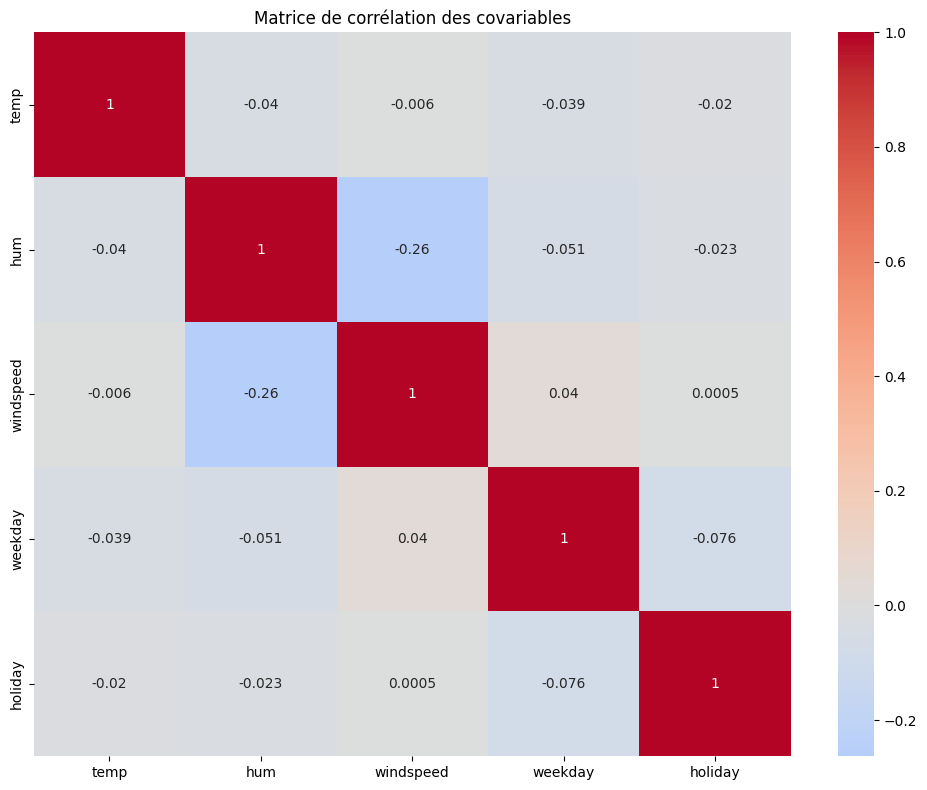

In [26]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des covariables')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100)
plt.show()

##### Répartition des données en ensemble d'entraînement et de test

In [28]:
# Division des données : 70% entraînement, 30% test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

In [31]:
"""
 Il est de noter que lorsque les données ne sont pas de meme unitées, une stardisation est nécessaire pour que
certaines variables ne dominent pas les autres dans les algorithmes d'apprentissage automatique.
"""
from sklearn.preprocessing import StandardScaler
    
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=covariables)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=covariables)

##### Modèle KNN

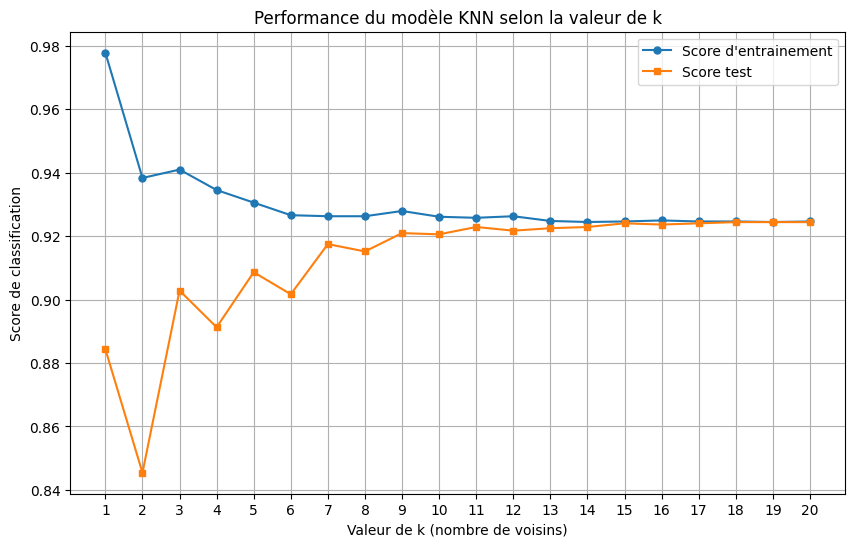

In [40]:
# Recherche du meilleur hyperparamètre k
from sklearn.neighbors import KNeighborsClassifier
k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Score d\'entrainement', markersize=5)
plt.plot(k_values, test_scores, 's-', label='Score test', markersize=5)
plt.xlabel('Valeur de k (nombre de voisins)')
plt.ylabel('Score de classification')
plt.title('Performance du modèle KNN selon la valeur de k')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

In [37]:
# Meilleur k
best_k = k_values[np.argmax(test_scores)]
print(f"Meilleure valeur de k : {best_k} (accuracy test = {max(test_scores):.4f})")

# Entraînement du meilleur modèle
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Évaluation
print("\nÉvaluation du modèle KNN:")
knn_scores = evaluate(best_knn, X_train_scaled, X_test_scaled, y_train, y_test)

Meilleure valeur de k : 18 (accuracy test = 0.9244)

Évaluation du modèle KNN:
RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[   6  451]
 [   5 5589]]
SCORE ACCURACY:
0.9246
RAPPORT CLASSIFICATION:
                    0            1  accuracy    macro avg  weighted avg
precision    0.545455     0.925331  0.924641     0.735393      0.896641
recall       0.013129     0.999106  0.924641     0.506118      0.924641
f1-score     0.025641     0.960805  0.924641     0.493223      0.890177
support    457.000000  5594.000000  0.924641  6051.000000   6051.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[   1  195]
 [   1 2397]]
SCORE ACCURACY:
0.9244
RAPPORT CLASSIFICATION:
                    0            1  accuracy    macro avg  weighted avg
precision    0.500000     0.924769  0.924441     0.712384      0.892673
recall       0.005102     0.999583  0.924441     0.502343      0.924441
f1-score     0.010101     0.960721  0.924441     0.485411      0.888894
support    196.000000  2398.000000  0.924441 

##### Analyse Discriminante Linéaire (LDA)

In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

print("\nÉvaluation du modèle LDA:")
lda_scores = evaluate(lda, X_train_scaled, X_test_scaled, y_train, y_test)



Évaluation du modèle LDA:
RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[   0  457]
 [   0 5594]]
SCORE ACCURACY:
0.9245
RAPPORT CLASSIFICATION:
               0            1  accuracy    macro avg  weighted avg
precision    0.0     0.924475  0.924475     0.462238      0.854655
recall       0.0     1.000000  0.924475     0.500000      0.924475
f1-score     0.0     0.960756  0.924475     0.480378      0.888195
support    457.0  5594.000000  0.924475  6051.000000   6051.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[   0  196]
 [   0 2398]]
SCORE ACCURACY:
0.9244
RAPPORT CLASSIFICATION:
               0            1  accuracy    macro avg  weighted avg
precision    0.0     0.924441  0.924441     0.462221      0.854591
recall       0.0     1.000000  0.924441     0.500000      0.924441
f1-score     0.0     0.960737  0.924441     0.480369      0.888145
support    196.0  2398.000000  0.924441  2594.000000   2594.000000


/home/layedev/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/layedev/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/layedev/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/layedev

In [43]:
# Informations supplémentaires
print("\nINFORMATIONS LDA:")
print(f"Coefficients : {lda.coef_[0]}")
print(f"Intercept : {lda.intercept_[0]}")
print(f"Priorités des classes : {lda.priors_}")
print(f"Moyennes des classes :\n{lda.means_}")


INFORMATIONS LDA:
Coefficients : [ 0.77446123 -0.44189252  0.11500598  0.11376028  0.0210275 ]
Intercept : 2.8556641438899923
Priorités des classes : [0.07552471 0.92447529]
Moyennes des classes :
[[-6.88303819e-01  4.46869197e-01 -1.98157699e-01 -9.45439165e-02
  -7.19515051e-03]
 [ 5.62307553e-02 -3.65068329e-02  1.61884284e-02  7.72373433e-03
   5.87805467e-04]]


##### Analyse Discriminante Quadratique (QDA)

In [44]:

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)

print("\nÉvaluation du modèle QDA:")
qda_scores = evaluate(qda, X_train_scaled, X_test_scaled, y_train, y_test)


Évaluation du modèle QDA:
RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[   0  457]
 [   0 5594]]
SCORE ACCURACY:
0.9245
RAPPORT CLASSIFICATION:
               0            1  accuracy    macro avg  weighted avg
precision    0.0     0.924475  0.924475     0.462238      0.854655
recall       0.0     1.000000  0.924475     0.500000      0.924475
f1-score     0.0     0.960756  0.924475     0.480378      0.888195
support    457.0  5594.000000  0.924475  6051.000000   6051.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[   0  196]
 [   0 2398]]
SCORE ACCURACY:
0.9244
RAPPORT CLASSIFICATION:
               0            1  accuracy    macro avg  weighted avg
precision    0.0     0.924441  0.924441     0.462221      0.854591
recall       0.0     1.000000  0.924441     0.500000      0.924441
f1-score     0.0     0.960737  0.924441     0.480369      0.888145
support    196.0  2398.000000  0.924441  2594.000000   2594.000000


/home/layedev/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/layedev/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/layedev/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/layedev

##### Analyse discrimante factorielle(FDA)

In [45]:
# FDA avec 1 composante (classification binaire)
fda = LinearDiscriminantAnalysis(n_components=1)
X_train_fda = fda.fit_transform(X_train_scaled, y_train)
X_test_fda = fda.transform(X_test_scaled)

print(f"Forme après transformation FDA : {X_train_fda.shape}")
print(f"Variance expliquée : {fda.explained_variance_ratio_[0]:.4f}")

Forme après transformation FDA : (6051, 1)
Variance expliquée : 1.0000


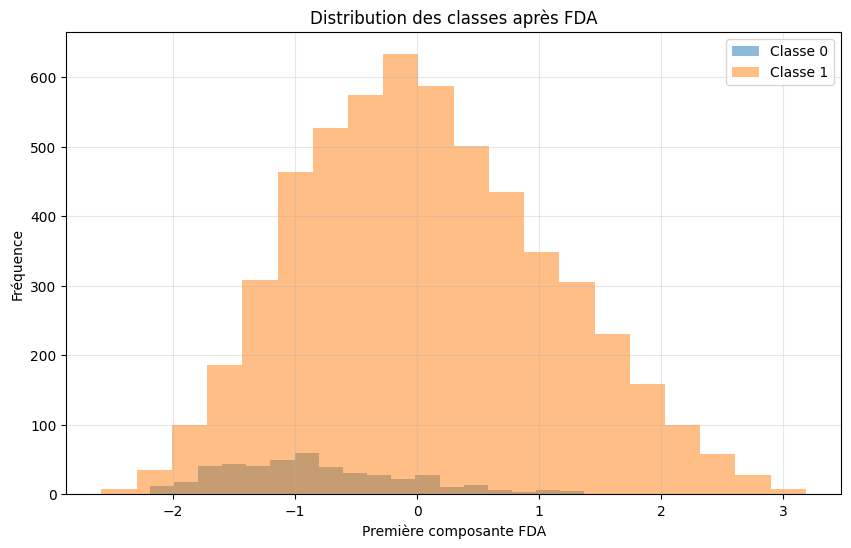

In [46]:
# Visualisation de la séparation
plt.figure(figsize=(10, 6))
for classe in [0, 1]:
    indices = y_train == classe
    plt.hist(X_train_fda[indices], alpha=0.5, label=f'Classe {classe}', bins=20)
plt.xlabel('Première composante FDA')
plt.ylabel('Fréquence')
plt.title('Distribution des classes après FDA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('fda_projection.png', dpi=100)
plt.show()

In [47]:
# Classification sur les données transformées
knn_fda = KNeighborsClassifier(n_neighbors=min(5, len(X_train_fda)))
knn_fda.fit(X_train_fda, y_train)

print("\nÉvaluation FDA + KNN:")
y_train_pred_fda = knn_fda.predict(X_train_fda)
y_test_pred_fda = knn_fda.predict(X_test_fda)

print(f"Accuracy sur entraînement : {accuracy_score(y_train, y_train_pred_fda):.4f}")
print(f"Accuracy sur test : {accuracy_score(y_test, y_test_pred_fda):.4f}")
print("\nMatrice de confusion (test):")
print(confusion_matrix(y_test, y_test_pred_fda))

fda_scores = {
    'train_accuracy': accuracy_score(y_train, y_train_pred_fda),
    'test_accuracy': accuracy_score(y_test, y_test_pred_fda)
}


Évaluation FDA + KNN:
Accuracy sur entraînement : 0.9286
Accuracy sur test : 0.9167

Matrice de confusion (test):
[[   9  187]
 [  29 2369]]


##### Comparaison des modèles

In [52]:
# Tableau comparatif
comparaison = pd.DataFrame({
    'Modèle': ['KNN', 'LDA', 'QDA', 'FDA + KNN'],
    'Accuracy Train': [
        best_knn.score(X_train_scaled, y_train),
        lda.score(X_train_scaled, y_train),
        qda.score(X_train_scaled, y_train),
        fda_scores['train_accuracy']
    ],
    'Accuracy Test': [
        best_knn.score(X_test_scaled, y_test),
        lda.score(X_test_scaled, y_test),
        qda.score(X_test_scaled, y_test),
        fda_scores['test_accuracy']
    ]
})

print("\nTABLEAU COMPARATIF:")
print(comparaison.to_string(index=False))


TABLEAU COMPARATIF:
   Modèle  Accuracy Train  Accuracy Test
      KNN        0.924641       0.924441
      LDA        0.924475       0.924441
      QDA        0.924475       0.924441
FDA + KNN        0.928607       0.916731


In [55]:
best_model_idx = comparaison['Accuracy Test'].idxmax()
best_model_name = comparaison.loc[best_model_idx, 'Modèle']
best_accuracy = comparaison.loc[best_model_idx, 'Accuracy Test']

print(f"\nMEILLEUR MODÈLE : {best_model_name}")
print(f"Accuracy sur test : {best_accuracy:.4f}")

print("\nINTERPRÉTATION:")
print("""
- KNN: Bon pour capturer des relations non-linéaires, mais sensible au choix de k
- LDA: Simple et rapide, suppose des distributions normales avec variances égales
- QDA: Plus flexible que LDA, peut mieux s'adapter aux données
- FDA: Réduit la dimensionnalité avant classification

Le meilleur modèle dépend des caractéristiques spécifiques des données.
""")


MEILLEUR MODÈLE : KNN
Accuracy sur test : 0.9244

INTERPRÉTATION:

- KNN: Bon pour capturer des relations non-linéaires, mais sensible au choix de k
- LDA: Simple et rapide, suppose des distributions normales avec variances égales
- QDA: Plus flexible que LDA, peut mieux s'adapter aux données
- FDA: Réduit la dimensionnalité avant classification

Le meilleur modèle dépend des caractéristiques spécifiques des données.

